In [ ]:
!sudo apt install -y fluidsynth
!pip install --upgrade pyfluidsynth
!pip install pretty_midi

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fluid-soundfont-gm libevdev2 libfluidsynth3 libgudev-1.0-0 libinput-bin
  libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a libqt5dbus5
  libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libxcb-icccm4 libxcb-image0 libxcb-keysyms1
  libxcb-render-util0 libxcb-util1 libxcb-xinerama0 libxcb-xinput0 libxcb-xkb1
  libxkbcommon-x11-0 qsynth qt5-gtk-platformtheme qttranslations5-l10n
  timgm6mb-soundfont
Suggested packages:
  fluid-soundfont-gs qt5-image-formats-plugins qtwayland5 jackd
The following NEW packages will be installed:
  fluid-soundfont-gm fluidsynth libevdev2 libfluidsynth3 libgudev-1.0-0
  libinput-bin libinput10 libinstpatch-1.0-2 libmd4c0 libmtdev1 libqt5core5a
  libqt5dbus5 libqt5gui5 libqt5network5 libqt5svg5 libqt5widgets5 libwacom-bin
  libwacom-common libwacom9 libx

In [ ]:
!git clone https://github.com/lucasnfe/vgmidi.git  #Videogame music dataset

Cloning into 'vgmidi'...
remote: Enumerating objects: 23026, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 23026 (delta 0), reused 1 (delta 0), pack-reused 23023 (from 1)
Receiving objects: 100% (23026/23026), 1.44 GiB | 18.46 MiB/s, done.
Resolving deltas: 100% (5529/5529), done.
Updating files: 100% (400/400), done.


In [ ]:
import collections
import datetime
import fluidsynth
import glob
import numpy as np
import pathlib
import pandas as pd
import pretty_midi
import seaborn as sns
import tensorflow as tf

from IPython import display
from matplotlib import pyplot as plt
from typing import Optional

In [ ]:
# All hyperparameters needed for training and generation

seed = 616
tf.random.set_seed(seed)
np.random.seed(seed)

# Sampling rate for audio playback
_SAMPLING_RATE = 20000

# Path to midi files
global_path = "TO_BE_DETERMINED"

# Training hyperparameters
NUMBER_OF_TRAINING_FILES = 20
TRAINING_SEQ_LENGTH = 50
VOCABULARY_SIZE = 128
BATCH_SIZE = 64
LEARNING_RATE = 1e-03
EPOCHS_NUM = 30

# Generation hyperparameters
TEMP = 2.0
PREDICTION_NUM = 120
DISPLAY_TIME = 45

In [ ]:
def display_audio(pm: pretty_midi.PrettyMIDI, seconds=DISPLAY_TIME):
  waveform = pm.fluidsynth(fs=_SAMPLING_RATE)
  # Take a sample of the generated waveform to mitigate kernel resets
  waveform_short = waveform[:seconds*_SAMPLING_RATE]
  return display.Audio(waveform_short, rate=_SAMPLING_RATE)

def midi_to_notes(midi_file: str) -> pd.DataFrame:
  pm = pretty_midi.PrettyMIDI(midi_file)
  instrument = pm.instruments[0]
  notes = collections.defaultdict(list)

  # Sort the notes by start time
  sorted_notes = sorted(instrument.notes, key=lambda note: note.start)
  prev_start = sorted_notes[0].start

  for note in sorted_notes:
    start = note.start
    end = note.end
    notes['pitch'].append(note.pitch)
    notes['start'].append(start)
    notes['end'].append(end)
    notes['step'].append(start - prev_start)
    notes['duration'].append(end - start)
    prev_start = start

  return pd.DataFrame({name: np.array(value) for name, value in notes.items()})

def plot_piano_roll(notes: pd.DataFrame, count: Optional[int] = None):
  if count:
    title = f'First {count} notes'
  else:
    title = f'Whole track'
    count = len(notes['pitch'])
  plt.figure(figsize=(20, 4))
  plot_pitch = np.stack([notes['pitch'], notes['pitch']], axis=0)
  plot_start_stop = np.stack([notes['start'], notes['end']], axis=0)
  plt.plot(
      plot_start_stop[:, :count], plot_pitch[:, :count], color="b", marker=".")
  plt.xlabel('Time [s]')
  plt.ylabel('Pitch')
  _ = plt.title(title)

def plot_distributions(notes: pd.DataFrame, drop_percentile=2.5):
  plt.figure(figsize=[15, 5])
  plt.subplot(1, 3, 1)
  sns.histplot(notes, x="pitch", bins=20)

  plt.subplot(1, 3, 2)
  max_step = np.percentile(notes['step'], 100 - drop_percentile)
  sns.histplot(notes, x="step", bins=np.linspace(0, max_step, 21))

  plt.subplot(1, 3, 3)
  max_duration = np.percentile(notes['duration'], 100 - drop_percentile)
  sns.histplot(notes, x="duration", bins=np.linspace(0, max_duration, 21))

def notes_to_midi(
  notes: pd.DataFrame,
  out_file: str,
  instrument_name: str,
  velocity: int = 100,  # note loudness
) -> pretty_midi.PrettyMIDI:

  pm = pretty_midi.PrettyMIDI()
  instrument = pretty_midi.Instrument(
      program=pretty_midi.instrument_name_to_program(
          instrument_name))

  prev_start = 0
  for i, note in notes.iterrows():
    start = float(prev_start + note['step'])
    end = float(start + note['duration'])
    note = pretty_midi.Note(
        velocity=velocity,
        pitch=int(note['pitch']),
        start=start,
        end=end,
    )
    instrument.notes.append(note)
    prev_start = start

  pm.instruments.append(instrument)
  pm.write(out_file)
  return pm

def create_sequences(
    dataset: tf.data.Dataset,
    seq_length: int,
    vocab_size = 128,
) -> tf.data.Dataset:
  """Returns TF Dataset of sequence and label examples."""
  seq_length = seq_length+1

  # Take 1 extra for the labels
  windows = dataset.window(seq_length, shift=1, stride=1,
                              drop_remainder=True)

  # `flat_map` flattens the" dataset of datasets" into a dataset of tensors
  flatten = lambda x: x.batch(seq_length, drop_remainder=True)
  sequences = windows.flat_map(flatten)

  # Normalize note pitch
  def scale_pitch(x):
    x = x/[vocab_size,1.0,1.0]
    return x

  # Split the labels
  def split_labels(sequences):
    inputs = sequences[:-1]
    labels_dense = sequences[-1]
    labels = {key:labels_dense[i] for i,key in enumerate(key_order)}

    return scale_pitch(inputs), labels

  return sequences.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)

def mse_with_positive_pressure(y_true: tf.Tensor, y_pred: tf.Tensor):
  mse = (y_true - y_pred) ** 2
  positive_pressure = 10 * tf.maximum(-y_pred, 0.0)
  return tf.reduce_mean(mse + positive_pressure)

def predict_next_note(
    notes: np.ndarray,
    model: tf.keras.Model,
    temperature: float = 1.0) -> tuple[int, float, float]:
  """Generates a note as a tuple of (pitch, step, duration), using a trained sequence model."""

  assert temperature > 0

  # Add batch dimension
  inputs = tf.expand_dims(notes, 0)

  predictions = model.predict(inputs)
  pitch_logits = predictions['pitch']
  step = predictions['step']
  duration = predictions['duration']

  pitch_logits /= temperature
  pitch = tf.random.categorical(pitch_logits, num_samples=1)
  pitch = tf.squeeze(pitch, axis=-1)
  duration = tf.squeeze(duration, axis=-1)
  step = tf.squeeze(step, axis=-1)

  # `step` and `duration` values should be non-negative
  step = tf.maximum(0, step)
  duration = tf.maximum(0, duration)

  return int(pitch), float(step), float(duration)

In [ ]:
# Maestro dataset
data_dir = pathlib.Path('data/maestro-v2_extracted/maestro-v2.0.0')
if not data_dir.exists():
  tf.keras.utils.get_file(
      'maestro-v2.0.0-midi.zip',
      origin='https://storage.googleapis.com/magentadata/datasets/maestro/v2.0.0/maestro-v2.0.0-midi.zip',
      extract=True,
      cache_dir='.', cache_subdir='data',
  )

In [ ]:
filenames = glob.glob(str(data_dir/'**/*.mid*'))  #str(data_dir/'**/*.mid*') str('vgmidi/unlabelled/midi/*.mid*')
print('Number of files:', len(filenames))
print(filenames[0::10])



Number of files: 1282
['data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MID--AUDIO_17_R1_2006_02_Track02_wav.midi', 'data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_15_R1_2006_01-05_ORIG_MID--AUDIO_15_R1_2006_04_Track04_wav.midi', 'data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_08_R2_2006_01_ORIG_MID--AUDIO_08_R2_2006_01_Track01_wav.midi', 'data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_23_R2_2006_01_ORIG_MID--AUDIO_23_R2_2006_01_Track01_wav.midi', 'data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_22_R1_2006_01-04_ORIG_MID--AUDIO_22_R1_2006_04_Track04_wav.midi', 'data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_07_R2_2006_01_ORIG_MID--AUDIO_07_R2_2006_01_Track01_wav.midi', 'data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_16_R1_2006_01-04_ORIG_MID--AUDIO_16_R1_2006_01_Track01_wav.midi', 'data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_14_R1_2006_0

In [ ]:
sample_file = filenames[1]
print(sample_file)
pm = pretty_midi.PrettyMIDI(sample_file)

#display_audio(pm)

print('Number of instruments:', len(pm.instruments))
instrument = pm.instruments[0]
instrument_name = pretty_midi.program_to_instrument_name(instrument.program)
print('Instrument name:', instrument_name)

for i, note in enumerate(instrument.notes[:10]):
  note_name = pretty_midi.note_number_to_name(note.pitch)
  duration = note.end - note.start
  print(f'{i}: pitch={note.pitch}, note_name={note_name},'
        f' duration={duration:.4f}')

raw_notes = midi_to_notes(sample_file)
print(raw_notes.head())

get_note_names = np.vectorize(pretty_midi.note_number_to_name)
sample_note_names = get_note_names(raw_notes['pitch'])
print(sample_note_names[:10])

data/maestro-v2_extracted/maestro-v2.0.0/2006/MIDI-Unprocessed_01_R1_2006_01-09_ORIG_MID--AUDIO_01_R1_2006_05_Track05_wav.midi
Number of instruments: 1
Instrument name: Acoustic Grand Piano
0: pitch=42, note_name=F#2, duration=0.1406
1: pitch=54, note_name=F#3, duration=0.1758
2: pitch=45, note_name=A2, duration=0.0547
3: pitch=57, note_name=A3, duration=0.0807
4: pitch=40, note_name=E2, duration=0.0885
5: pitch=52, note_name=E3, duration=0.0938
6: pitch=41, note_name=F2, duration=0.0729
7: pitch=53, note_name=F3, duration=0.1380
8: pitch=62, note_name=D4, duration=0.1510
9: pitch=50, note_name=D3, duration=0.1510
   pitch     start       end      step  duration
0     54  0.151042  0.326823  0.000000  0.175781
1     42  0.186198  0.326823  0.035156  0.140625
2     57  0.312500  0.393229  0.126302  0.080729
3     45  0.313802  0.368490  0.001302  0.054688
4     40  0.393229  0.481771  0.079427  0.088542
['F#3' 'F#2' 'A3' 'A2' 'E2' 'E3' 'F2' 'F3' 'D4' 'D3']


## Create the training dataset

In [ ]:
num_files = NUMBER_OF_TRAINING_FILES
all_notes = []
for f in filenames[:num_files]:
  notes = midi_to_notes(f)
  all_notes.append(notes)

all_notes = pd.concat(all_notes)

n_notes = len(all_notes)
print('Number of notes parsed:', n_notes)

Number of notes parsed: 101934


Next, create a `tf.data.Dataset` from the parsed notes.
\
Set the sequence length for each example. Experiment with different lengths (e.g. 50, 100, 150) to see which one works best for the data, or use [hyperparameter tuning](https://www.tensorflow.org/tutorials/keras/keras_tuner). The size of the vocabulary (`vocab_size`) is set to 128 representing all the pitches supported by `pretty_midi`.

In [ ]:
key_order = ['pitch', 'step', 'duration']
train_notes = np.stack([all_notes[key] for key in key_order], axis=1)
notes_ds = tf.data.Dataset.from_tensor_slices(train_notes)

seq_length = TRAINING_SEQ_LENGTH
vocab_size = VOCABULARY_SIZE
seq_ds = create_sequences(notes_ds, seq_length, vocab_size)
seq_ds.element_spec

for seq, target in seq_ds.take(1):
  print('sequence shape:', seq.shape)
  print('sequence elements (first 10):', seq[0: 10])
  print()
  print('target:', target)

batch_size = BATCH_SIZE
buffer_size = n_notes - seq_length  # the number of items in the dataset
train_ds = (seq_ds
            .shuffle(buffer_size)
            .batch(batch_size, drop_remainder=True)
            .cache()
            .prefetch(tf.data.experimental.AUTOTUNE))

sequence shape: (50, 3)
sequence elements (first 10): tf.Tensor(
[[5.31250000e-01 0.00000000e+00 1.51041667e-01]
 [4.37500000e-01 1.95312500e-02 3.98437500e-01]
 [4.60937500e-01 3.90625000e-03 4.02343750e-01]
 [2.50000000e-01 6.51041667e-03 5.54687500e-01]
 [3.43750000e-01 1.30208333e-03 5.71614583e-01]
 [4.92187500e-01 1.22395833e-01 3.02083333e-01]
 [4.92187500e-01 9.68750000e-01 3.32161458e+00]
 [4.21875000e-01 1.30208333e-02 2.46093750e+00]
 [4.60937500e-01 1.30208333e-03 2.89062500e+00]
 [3.67187500e-01 2.08333333e-02 3.33854167e+00]], shape=(10, 3), dtype=float64)

target: {'pitch': <tf.Tensor: shape=(), dtype=float64, numpy=59.0>, 'step': <tf.Tensor: shape=(), dtype=float64, numpy=0.3046875>, 'duration': <tf.Tensor: shape=(), dtype=float64, numpy=0.31640625>}


## Create and train the model

The model will have three outputs, one for each note variable. For `step` and `duration`, you will use a custom loss function based on mean squared error that encourages the model to output non-negative values.

In [ ]:
input_shape = (seq_length, 3)
learning_rate = LEARNING_RATE

inputs = tf.keras.Input(input_shape)
x = tf.keras.layers.LSTM(128)(inputs)

outputs = {
  'pitch': tf.keras.layers.Dense(128, name='pitch')(x),
  'step': tf.keras.layers.Dense(1, name='step')(x),
  'duration': tf.keras.layers.Dense(1, name='duration')(x),
}

model = tf.keras.Model(inputs, outputs)

loss = {
      'pitch': tf.keras.losses.SparseCategoricalCrossentropy(
          from_logits=True),
      'step': mse_with_positive_pressure,
      'duration': mse_with_positive_pressure,
}

optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

model.compile(loss=loss, optimizer=optimizer)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 50, 3)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 128)       │     67,584 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ duration (Dense)    │ (None, 1)         │        129 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pitch (Dense)       │ (None, 128)       │     16,512 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ step (Dense)        │ (None, 1)         │        129 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 84,354 (329.51 KB)

 Trainable params: 84,354 (329.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
losses = model.evaluate(train_ds, return_dict=True)
losses

1591/1591 ━━━━━━━━━━━━━━━━━━━━ 76s 32ms/step - duration_loss: 0.8335 - loss: 5.7681 - pitch_loss: 4.8554 - step_loss: 0.0793


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


{'duration_loss': 0.8530543446540833,
 'loss': 5.795595645904541,
 'pitch_loss': 4.852225303649902,
 'step_loss': 0.09031419456005096}

In [ ]:
model.compile(
    loss=loss,
    loss_weights={
        'pitch': 0.02,
        'step': 1.2,
        'duration':1.0,
    },
    optimizer=optimizer,
)

model.evaluate(train_ds, return_dict=True)

1591/1591 ━━━━━━━━━━━━━━━━━━━━ 53s 32ms/step - duration_loss: 0.8335 - loss: 1.0258 - pitch_loss: 4.8554 - step_loss: 0.0793


{'duration_loss': 0.8530543446540833,
 'loss': 1.0584763288497925,
 'pitch_loss': 4.852225303649902,
 'step_loss': 0.09031419456005096}

In [41]:
%%time
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath='./training_checkpoints/ckpt_{epoch}.weights.h5',
        save_weights_only=True),
    tf.keras.callbacks.EarlyStopping(
        monitor='loss',
        patience=5,
        verbose=1,
        restore_best_weights=True),
]


epochs = EPOCHS_NUM

history = model.fit(
    train_ds,
    epochs=epochs,
    callbacks=callbacks,
)

Epoch 1/30
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 116s 73ms/step - duration_loss: 0.1220 - loss: 0.2716 - pitch_loss: 4.0352 - step_loss: 0.0574
Epoch 2/30
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 116s 73ms/step - duration_loss: 0.1210 - loss: 0.2681 - pitch_loss: 3.9439 - step_loss: 0.0568
Epoch 3/30
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 146s 92ms/step - duration_loss: 0.1202 - loss: 0.2658 - pitch_loss: 3.9041 - step_loss: 0.0563
Epoch 4/30
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 117s 74ms/step - duration_loss: 0.1194 - loss: 0.2639 - pitch_loss: 3.8835 - step_loss: 0.0557
Epoch 5/30
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 116s 73ms/step - duration_loss: 0.1184 - loss: 0.2622 - pitch_loss: 3.8867 - step_loss: 0.0551
Epoch 6/30
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 116s 73ms/step - duration_loss: 0.1175 - loss: 0.2610 - pitch_loss: 3.8832 - step_loss: 0.0548
Epoch 7/30
1591/1591 ━━━━━━━━━━━━━━━━━━━━ 116s 73ms/step - duration_loss: 0.1169 - loss: 0.2597 - pitch_loss: 3.8857 - step_loss: 0.0542
Epoch 8/30
1591/1591 ━━━━━━━━━━━━━━━━━━━━

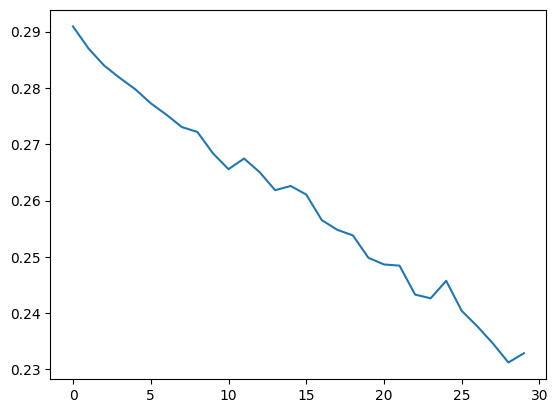

In [42]:
plt.plot(history.epoch, history.history['loss'], label='total loss')
plt.show()

In [43]:
temperature = TEMP
num_predictions = PREDICTION_NUM

sample_notes = np.stack([raw_notes[key] for key in key_order], axis=1)

# The initial sequence of notes; pitch is normalized similar to training
# sequences
input_notes = (
    sample_notes[:seq_length] / np.array([vocab_size, 1, 1]))

generated_notes = []
prev_start = 0
for _ in range(num_predictions):
  pitch, step, duration = predict_next_note(input_notes, model, temperature)
  start = prev_start + step
  end = start + duration
  input_note = (pitch, step, duration)
  generated_notes.append((*input_note, start, end))
  input_notes = np.delete(input_notes, 0, axis=0)
  input_notes = np.append(input_notes, np.expand_dims(input_note, 0), axis=0)
  prev_start = start

generated_notes = pd.DataFrame(
    generated_notes, columns=(*key_order, 'start', 'end'))
generated_notes.head(10)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━

,pitch,step,duration,start,end
0,60,0.612955,0.257834,0.612955,0.870789
1,96,0.932989,0.255946,1.545943,1.801889
2,86,1.098876,0.273373,2.644819,2.918192
3,84,1.097382,0.293447,3.742201,4.035648
4,91,1.097667,0.296449,4.839869,5.136318
5,94,1.099787,0.295094,5.939656,6.234750
6,83,1.101988,0.293243,7.041644,7.334887
7,85,1.104825,0.291204,8.146469,8.437672
8,92,1.107902,0.289669,9.254371,9.544039
9,97,1.109364,0.288916,10.363734,10.652651


In [44]:
out_file = 'output.mid'
out_pm = notes_to_midi(
    generated_notes, out_file=out_file, instrument_name=instrument_name)
display_audio(out_pm)

In [ ]:
from google.colab import files
files.download(out_file)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

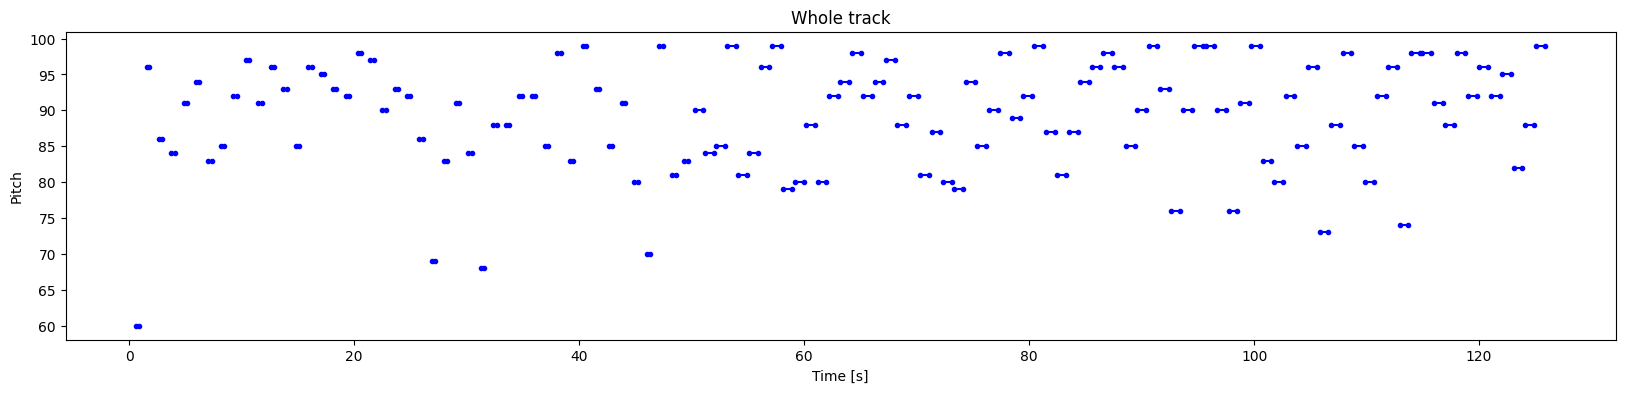

In [45]:
plot_piano_roll(generated_notes)

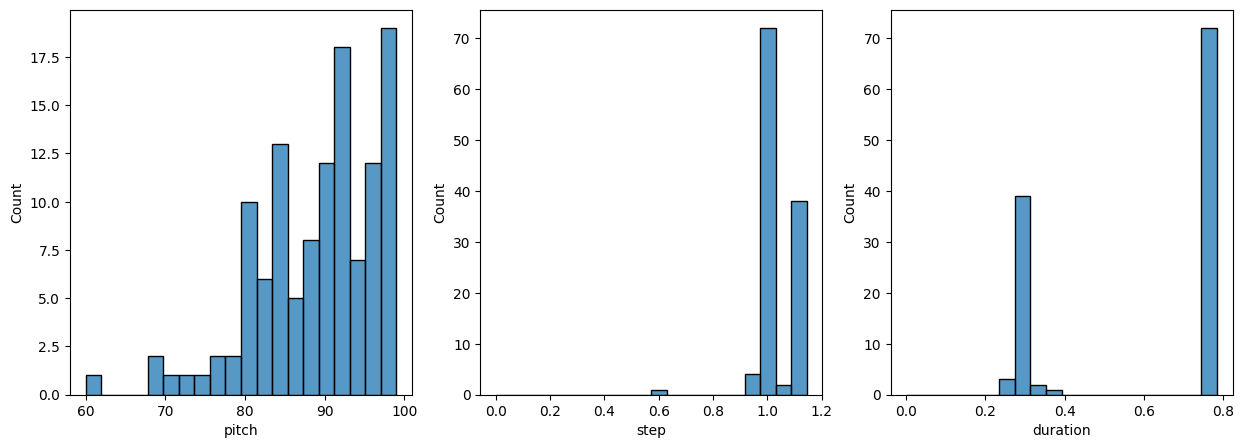

In [46]:
plot_distributions(generated_notes)

In the above plots, you will notice the change in distribution of the note variables.
Since there is a feedback loop between the model's outputs and inputs, the model tends to generate similar sequences of outputs to reduce the loss.
This is particularly relevant for `step` and `duration`, which uses the MSE loss.
For `pitch`, you can increase the randomness by increasing the `temperature` in `predict_next_note`.